In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import random
from collections import Counter

In [2]:
#df=pd.read_csv('D:/mhx/daima/pachong/zhibopachong/dataprocess/BGxM3akaUZYjTlaZ7bZi9th9e34npLl6.csv')
df=pd.read_csv('D:/social network1/daima/pachong/zhibopachong/dataprocess/BGxM3akaUZYjTlaZ7bZi9th9e34npLl6.csv')
df.head(5)

,avg_residence_time,crawl_time,follower_count,follower_count_incr,gift_uv_count,increment_follow_count,increment_follow_count_incr,leave_user,like_count,like_count_incr,...,room_ticket_count_incr,status,status_v2,time_node,total_user,total_user_incr,user_count,user_count_incr,user_peak,watch_cnt
0,0,1682254298,3217,0,0,0,0,0,0,0,...,0,0,0,1682254260,0,0,0,0,0,0
1,0,1682254378,3217,0,0,0,0,0,0,0,...,0,2,0,1682254320,0,0,0,0,0,0
2,30,1682254392,3217,0,0,0,0,0,0,0,...,0,2,0,1682254380,1,1,1,1,1,1
3,28,1682254991,3218,1,0,1,1,2,0,0,...,0,2,0,1682254980,21,20,1,0,1,21
4,41,1682256196,3218,0,0,1,0,1,0,0,...,0,2,0,1682256180,49,28,1,0,1,49


# 1 直播网络快照

In [3]:
def add_remove(G,t,to_remove):
    # 添加新节点和新边
    new_node =list(range(G.number_of_nodes(), G.number_of_nodes()+df['real_time_user'][t]))
    for i in new_node:
        G.add_node(i)
        new_node_idx = G.number_of_nodes() - 1
        for j in range(new_node_idx):
            G.add_edge(new_node_idx, j)
    # 随机选择要退出的节点
    # 设置随机种子
    random.seed(42)
    to_remove.extend(random.sample(range ( 1, G.number_of_nodes()), df['leave_user'][t]))
    # 从图中删除leave_user其相连的边
    for node in to_remove:
        neighbors = list(G.neighbors(node))
        for neighbor in neighbors:
            G.remove_edge(node, neighbor)
    return G,to_remove,new_node

In [4]:
def generate_snapshots(num_snapshots):
    snapshots = []
    to_remove = []
    G = nx.complete_graph(1)
    for t in range(0, num_snapshots):
        G, to_remove, new_node = add_remove(G, t, to_remove)
        snapshots.append(G.copy())
        if t+1==num_snapshots:
            break
    return snapshots
# 生成网络快照
snapshots= generate_snapshots(df.shape[0])

每张快照节点一致

In [5]:
def convert_to_max_nodes(photo,max_nodes):
    convert_snapshots=[]
    for snapshot in photo:
        snapshot_copy=snapshot.copy()#防止改变snapshots的大小
        #获取当前快照的节点数
        num_nodes=snapshot_copy.number_of_nodes()
        if num_nodes<max_nodes:
            #添加额外的节点使其达到最大节点数
            extra_nodes=max_nodes-num_nodes
            new_nodes=list(range(num_nodes,num_nodes+extra_nodes))
            snapshot_copy.add_nodes_from(new_nodes)
        convert_snapshots.append(snapshot_copy)
    return convert_snapshots
#读取最后一张快照的节点数
last_snapshot=snapshots[-1]
max_nodes=last_snapshot.number_of_nodes()#58
convert_snapshots=convert_to_max_nodes(snapshots,max_nodes)

# 草稿

In [17]:
AL_AGG = nx.Graph()
al_agg = np.zeros((max_nodes, max_nodes))
#al_agg = np.zeros((nodes, nodes))
for go in convert_snapshots:
    go = nx.convert_node_labels_to_integers(go, first_label=0, ordering="sorted")
    AL_AGG = nx.compose(AL_AGG, go)
    al_agg += nx.to_numpy_matrix(go)

节点特征

In [18]:
edge_list=[]
node_list=[]
node_dict={}#空字典用于储存节点第一次出现的时间
#提取节点和边的事件
for i,snapshot in enumerate(snapshots):
    edges=[(u,v,i) for u,v in snapshot.edges()]
    nodes=list(snapshot.nodes())
    edge_list.extend(edges)
    for node in nodes:
        if node not in node_dict:
            node_dict[node]=i
df_edge_time=pd.DataFrame(edge_list,columns=['source','target','online_time'])
df_node_time=pd.DataFrame(node_dict.items(),columns=['node','online_time'])

In [19]:
num_snapshots=df.shape[0]
#读取最后一张快照的节点数
last_snapshot=snapshots[-1]
max_nodes=last_snapshot.number_of_nodes()#58

In [20]:
def add_remove_time(G,t,to_remove,earliest_disappear_time):
    # 添加新节点和新边
    new_node =list(range(G.number_of_nodes(), G.number_of_nodes()+df['real_time_user'][t]))
    for i in new_node:
        G.add_node(i)
        new_node_idx = G.number_of_nodes() - 1
        for j in range(new_node_idx):
            G.add_edge(new_node_idx, j)
    # 随机选择要退出的节点
    # 设置随机种子
    random.seed(42)
    to_remove.extend(random.sample(range ( 1, G.number_of_nodes()), df['leave_user'][t]))

    #记录节点下线的时间戳
    for node in to_remove:
        if earliest_disappear_time[node] is None or t<earliest_disappear_time[node]:
            earliest_disappear_time[node]=t
    
    # 从图中删除leave_user其相连的边
    for node in to_remove:
        neighbors = list(G.neighbors(node))
        for neighbor in neighbors:
            G.remove_edge(node, neighbor)
    return G,to_remove,new_node,earliest_disappear_time

In [21]:
snapshots_time = []
to_remove = []
earliest_disappear_time=[None]*max_nodes
G = nx.complete_graph(1)
for t in range(0, num_snapshots):
    G, to_remove, new_nodes, earliest_disappear_time= add_remove_time(G, t, to_remove,earliest_disappear_time)
    snapshots_time.append(G.copy())

In [22]:
last_snapshot_idx=df.shape[0]-1
for i,timestamp in enumerate(earliest_disappear_time):
    if timestamp is None:
        earliest_disappear_time[i]=last_snapshot_idx

In [23]:
df_node_disappear=pd.DataFrame({'node':range(len(earliest_disappear_time)),'offline_time':earliest_disappear_time})
df_node_time=pd.merge(df_node_time,df_node_disappear,on='node',how='left')

In [24]:
#度
degree=dict(AL_AGG.degree())
#聚类系数
clustering_coefficient=nx.clustering(AL_AGG)
#介数中心性
centrality=nx.betweenness_centrality(AL_AGG)
df_node_structure=pd.DataFrame(columns=['node','degree','clustering_coefficient','centrality'])
for node in AL_AGG.nodes():
    row={'node':int(node),'degree':degree[node],'clustering_coefficient':clustering_coefficient[node],'centrality':centrality[node]}
    df_node_structure=df_node_structure.append(row,ignore_index=True)

In [25]:
df_nodes=pd.merge(df_node_time,df_node_structure,on='node',how='left')

In [26]:
df_nodes

,node,online_time,offline_time,degree,clustering_coefficient,centrality
0,0,0,88,53.0,0.673440,0.117966
1,1,2,3,1.0,0.000000,0.000000
2,2,3,6,4.0,1.000000,0.000000
3,3,3,3,0.0,0.000000,0.000000
4,4,4,8,7.0,0.857143,0.000470
5,5,5,8,7.0,0.857143,0.000470
6,6,5,5,0.0,0.000000,0.000000
7,7,5,63,39.0,0.690958,0.044495
8,8,6,14,15.0,0.695238,0.004677
9,9,7,14,15.0,0.695238,0.004677


边的特征

In [27]:
edge_disappear_time=[]
for index,row in df_edge_time.iterrows():
    source=row['source']
    target=row['target']
    edge_appear_time=row['online_time']
    #在数据框中查询边出现后的所有记录
    later_records=df_edge_time[(df_edge_time['source']==source)&(df_edge_time['target']==target)&(df_edge_time['online_time']>edge_appear_time)]
    #若存在后续记录，取出最大的时间戳作为边的消失时间戳
    if not later_records.empty:
        disappear_time=later_records['online_time'].max()+1#下一时间戳下线
    else:
        disappear_time=edge_appear_time+1
    edge_disappear_time.append(disappear_time)
df_edge_time['offline_time']=edge_disappear_time
#删除重复边，只保留出现时间最小的行
df_edge_time=df_edge_time[~df_edge_time.duplicated(subset=['source','target'],keep='first')]

In [28]:
#边的介数中心性
edge_betweenness=nx.edge_betweenness_centrality(AL_AGG)
#权重
edge_frequency={}
for snapshot in snapshots:
    for edge in snapshot.edges():
        if edge in edge_frequency:
            edge_frequency[edge]+=1
        else:
            edge_frequency[edge]=0
df_edge_structure=pd.DataFrame(columns=['edge','edge_betweenness','frequency'])
for edge,frequency in edge_frequency.items():
    row={'edge':edge,'edge_betweenness':edge_betweenness[edge],'frequency':edge_frequency[edge] }
    df_edge_structure=df_edge_structure.append(row,ignore_index=True)
#将edge转换为source,target
df_edge_structure['source']=""
df_edge_structure['target']=""
for index,row in df_edge_structure.iterrows():
    edge=row['edge']
    source,target=edge[0],edge[1]
    df_edge_structure.at[index,'source']=source
    df_edge_structure.at[index,'target']=target
df_edge_structure=df_edge_structure.drop(columns=['edge'])

In [29]:
df_edges=pd.merge(df_edge_time,df_edge_structure,on=['source','target'],how='left')
#将object转换为int，为了后续的张量转换
cols_to_convert=['source','target','frequency']
df_edges[cols_to_convert]=df_edges[cols_to_convert].astype(int)

In [30]:
df_edges

,source,target,online_time,offline_time,edge_betweenness,frequency
0,0,1,2,3,0.032063,0
1,0,2,3,6,0.019208,2
2,0,4,4,8,0.017393,3
3,2,4,4,6,0.001059,1
4,0,5,5,8,0.017393,2
...,...,...,...,...,...,...
976,52,57,83,89,0.000605,5
977,53,57,83,89,0.000605,5
978,54,57,83,89,0.000605,5
979,55,57,83,89,0.000605,5


# 2 模型的输入

## 2.1 节点结构特征

In [6]:
#聚合图列表
aggregated_graphs=[]
aggregated_graph=nx.Graph()
for graph in convert_snapshots:
    aggregated_graph=nx.compose(aggregated_graph,graph)
    aggregated_graphs.append(aggregated_graph.copy())

In [7]:
#结构特征
def node_structure_feature(graphs):
    node_features=[]
    for graph in graphs:
        #度
        degrees=dict(graph.degree())
        #聚类系数
        clustering_coefficients=nx.clustering(graph)
        #介数中心性
        centralitys=nx.betweenness_centrality(graph)
        
        features=[]
        for node in graph.nodes:
            degree=degrees[node]
            clustering_coefficient=clustering_coefficients[node]
            centrality=centralitys[node]
            features.append([degree,clustering_coefficient,centrality])
        node_features.append(features)
    return np.array(node_features)

In [8]:
node_features=node_structure_feature(aggregated_graphs)

In [9]:
node_features

array([[[ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        ...,
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ]],

       [[ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        ...,
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ]],

       [[ 1.        ,  0.        ,  0.        ],
        [ 1.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        ...,
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ]],

       ...,

       [[53.        ,  0.67343977,  0.11796588],
        [ 1

## 2.2 节点时间特征

In [10]:
def is_online(G,max_nodes,new_node,to_remove):
    red_node=set(new_node)
    blue_node=set(to_remove)
    all_node=set(G.nodes())
    gree_node=all_node-red_node-blue_node
    max_node={num for num in range(max_nodes)}
    other_node=max_node-all_node
    #检查每个节点是否在线
    online_status={}
    for node in red_node:
        online_status[node]=1
    for node in gree_node:
        online_status[node]=1
    for node in blue_node:
        online_status[node]=0
    for node in other_node:
        online_status[node]=0
    value_sort=[online_status[key] for key in sorted(online_status.keys())]
    df_online_status=pd.DataFrame(value_sort,columns=['online_status'])
    
    return np.array(df_online_status)

In [11]:
to_remove = []
all_online_status=[]
G = nx.complete_graph(1)
for t in range(0, df.shape[0]):
    G, to_remove, new_node = add_remove(G, t, to_remove.copy())
    sort_online_status=is_online(G,max_nodes,new_node,to_remove)
    all_online_status.append(sort_online_status.copy())
all_online_status=np.array(all_online_status)

In [12]:
all_online_status

array([[[1],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]],

       [[1],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]],

       [[1],
        [1],
        [0],
        ...,
        [0],
        [0],
        [0]],

       ...,

       [[1],
        [0],
        [0],
        ...,
        [1],
        [1],
        [1]],

       [[1],
        [0],
        [0],
        ...,
        [1],
        [1],
        [1]],

       [[1],
        [0],
        [0],
        ...,
        [1],
        [1],
        [1]]], dtype=int64)

## 2.3 合并特征

In [13]:
node_features.shape

(89, 58, 3)

In [14]:
all_online_status.shape

(89, 58, 1)

In [15]:
node_features_new=np.concatenate((node_features,all_online_status),axis=2)
node_features_new

array([[[ 0.        ,  0.        ,  0.        ,  1.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ],
        ...,
        [ 0.        ,  0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ]],

       [[ 0.        ,  0.        ,  0.        ,  1.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ],
        ...,
        [ 0.        ,  0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ]],

       [[ 1.        ,  0.        ,  0.        ,  1.        ],
        [ 1.        ,  0.        ,  0.        ,  1.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ],
        ...,
        [ 0.        ,  0.  

# 3 模型

In [16]:
import numpy as np
import networkx as nx
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from torch_geometric.data import Data,DataLoader, Batch
from torch_geometric.nn import global_mean_pool

## 3.1 网络嵌入+信息传播

In [10]:
# 定义GraphSAGE模型
class GraphSAGE(nn.Module):
    def __init__(self, in_feats, hidden_size, num_classes):
        super(GraphSAGE, self).__init__()
        self.conv1 = SAGEConv(in_feats, hidden_size)
        self.conv2 = SAGEConv(hidden_size, hidden_size)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = self.fc(x)
        return F.log_softmax(x, dim=1)

In [82]:
# 定义独立级联模型
class IndependentCascadeModel:
    def __init__(self, threshold = 0.5):
        self.threshold = threshold

    def propagate(self,graphs,node_features, seed_nodes):
        active_nodes = [set(seed_nodes)]*len(graphs)
        new_active_nodes = [set(seed_nodes)]*len(graphs)

        while any(new_active_nodes):
            next_active_nodes = [set() for _ in range(len(graphs))]
            for i,graph in enumerate(graphs):
                for node in new_active_nodes[i]:
                    neighbors = graph.neighbors(node)
                    for neighbor in neighbors:
                        if neighbor in active_nodes[i]:
                            continue
                        neighbor_features = node_features[i][neighbor]
                        if np.random.random() < self.threshold:
                            next_active_nodes[i].add(neighbor)
                            active_nodes[i].add(neighbor)
            new_active_nodes = next_active_nodes

        return active_nodes

In [102]:
# 构建网络嵌入模块
def embed_network(graphs, node_features_new, hidden_size, num_classes):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    embeddings=[]
    for garph_idx,graph in enumerate(graphs):
        node_features_new=node_features_new[garph_idx]
    
        if graph.number_of_edges()>0:
            x=torch.tensor(node_features_new,dtype=torch.float32).to(device)
            edge_index = torch.tensor(list(graph.edges)).t().contiguous().to(device).to(torch.long)
            if edge_index.dim()==1:
                edge_index=edge_index.view(-1,2)
        else:
            x = torch.zeros(x.shape[0],dtype=torch.float32).to(device)
            edge_index = torch.tensor([],dtype=torch.long).to(device)
            zero_embedding=torch.zeros((x.shape[0],hidden_size),dtype=torch.float32).to(device)
            embeddings.append(zero_embedding)
            del x
            continue
            
        model = GraphSAGE(x.shape[1], hidden_size, num_classes).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.01)
        criterion = nn.NLLLoss()

        model.train()
        for epoch in range(100):
            optimizer.zero_grad()
            out = model(x, edge_index)
            y = torch.tensor(labels, dtype=torch.long).to(device)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            embedding = model(x, edge_index).cpu().numpy()
            embeddings.append(embedding)
        del x

    return embeddings

In [29]:
graphs=convert_snapshots

In [43]:
def assign_labels(num_nodes,probability,num_ones):
    labels=[1]*num_ones+[0]*(num_nodes-num_ones)
    random.shuffle(labels)
    return labels
num_nodes=max_nodes
probability=0.4168
num_ones=int(num_nodes*probability)
labels=assign_labels(num_nodes,probability,num_ones)

In [103]:
# 使用GraphSAGE进行网络嵌入
embeddings = embed_network(graphs, node_features, hidden_size=64, num_classes=2)
# 构建独立级联模型
ic_model = IndependentCascadeModel()
# 设置种子节点
seed_nodes = [0]
# 进行信息传播
active_nodes = ic_model.propagate(graphs,embeddings,seed_nodes)
print("Active nodes:", active_nodes)

Active nodes: [{0, 2, 4, 5, 7, 8, 9, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57}, {0, 2, 4, 5, 7, 8, 9, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57}, {0, 2, 4, 5, 7, 8, 9, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57}, {0, 2, 4, 5, 7, 8, 9, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57}, {0, 2, 4, 5, 7, 8, 9, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,

模型不完全正确，如将误差放入了嵌入模块、信息级联中没有将网络快照视为有时间顺序的网络快照等。但是根据模型的输出可以肯定使用信息级联模型达不到想要的目的。

## 3.2 网络嵌入+观点动力学——静态网络

In [93]:
# 定义GraphSAGE模型
class GraphSAGE(nn.Module):
    def __init__(self, in_feats, hidden_size, num_classes):
        super(GraphSAGE, self).__init__()
        self.conv1 = SAGEConv(in_feats, hidden_size)
        self.conv2 = SAGEConv(hidden_size, hidden_size)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = self.fc(x)
        return F.log_softmax(x, dim=1)

In [126]:
# 模型参数
epsilon = 0.1
max_iterations = 10
# 观点的动力学（使用HK模型）
def hk_model(opinions, features, epsilon, max_iterations):
    num_agents = len(opinions)
    iteration = 0

    while iteration < max_iterations:
        new_opinions = np.copy(opinions)

        for i in range(num_agents):
            similar_opinions = []
            for j in range(num_agents):
                if abs(opinions[j]-opinions[i]) < epsilon:
                    similar_opinions.append(features[j])

            if len(similar_opinions) > 0:
                similar_opinions = np.array(similar_opinions)
                new_opinions[i] = np.mean(similar_opinions, axis=0)

        opinions = np.copy(new_opinions)
        iteration += 1

    return opinions

In [124]:
# 数据准备
last_snapshot=snapshots[-1]
max_nodes=last_snapshot.number_of_nodes()#58
initial_opinions=np.random.normal(loc=0.5,scale=0.1,size=max_nodes)
# 将 node_features_new 转换为 PyTorch 张量
node_features_tensor = torch.tensor(node_features_new[-1], dtype=torch.float32)
# 构造 Data 对象，用于表示图数据
data = Data(x=node_features_tensor, edge_index=torch.tensor(list(last_snapshot.edges())).t().contiguous())

In [125]:
#标签设置
def assign_labels(num_nodes,probability,num_ones):
    labels=[1]*num_ones+[0]*(num_nodes-num_ones)
    random.shuffle(labels)
    return labels
num_nodes=max_nodes
probability=0.4168
num_ones=int(num_nodes*probability)
labels=assign_labels(num_nodes,probability,num_ones)

In [129]:
model = GraphSAGE(data.x.size(-1), 16, 1)
optimizer = optim.Adam(model.parameters(), lr=0.01)
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    
    # 使用HK模型更新观点
    opinions = hk_model(initial_opinions,out.detach().numpy(), epsilon, max_iterations)
    actions = torch.tensor(opinions, dtype=torch.float32, requires_grad=True).view(-1, 1)
    
    # 计算损失函数
    loss = nn.MSELoss()(actions, torch.tensor(labels, dtype=torch.float32).view(-1, 1))
    
    # 反向传播和参数更新
    loss.backward()
    optimizer.step()
    
    return loss.item()

# 训练模型
num_epochs = 100
for epoch in range(num_epochs):
    loss = train()
    print(f"Epoch: {epoch+1}, Loss: {loss:.4f}")

Epoch: 1, Loss: 0.4138
Epoch: 2, Loss: 0.4138
Epoch: 3, Loss: 0.4138
Epoch: 4, Loss: 0.4138
Epoch: 5, Loss: 0.4138
Epoch: 6, Loss: 0.4138
Epoch: 7, Loss: 0.4138
Epoch: 8, Loss: 0.4138
Epoch: 9, Loss: 0.4138
Epoch: 10, Loss: 0.4138
Epoch: 11, Loss: 0.4138
Epoch: 12, Loss: 0.4138
Epoch: 13, Loss: 0.4138
Epoch: 14, Loss: 0.4138
Epoch: 15, Loss: 0.4138
Epoch: 16, Loss: 0.4138
Epoch: 17, Loss: 0.4138
Epoch: 18, Loss: 0.4138
Epoch: 19, Loss: 0.4138
Epoch: 20, Loss: 0.4138
Epoch: 21, Loss: 0.4138
Epoch: 22, Loss: 0.4138
Epoch: 23, Loss: 0.4138
Epoch: 24, Loss: 0.4138
Epoch: 25, Loss: 0.4138
Epoch: 26, Loss: 0.4138
Epoch: 27, Loss: 0.4138
Epoch: 28, Loss: 0.4138
Epoch: 29, Loss: 0.4138
Epoch: 30, Loss: 0.4138
Epoch: 31, Loss: 0.4138
Epoch: 32, Loss: 0.4138
Epoch: 33, Loss: 0.4138
Epoch: 34, Loss: 0.4138
Epoch: 35, Loss: 0.4138
Epoch: 36, Loss: 0.4138
Epoch: 37, Loss: 0.4138
Epoch: 38, Loss: 0.4138
Epoch: 39, Loss: 0.4138
Epoch: 40, Loss: 0.4138
Epoch: 41, Loss: 0.4138
Epoch: 42, Loss: 0.4138
E

在反向传播过程中损失没有下降，可能有几个原因：1.学习率过大或过小 2.模型设计问题 3.数据问题 4.过拟合 5.训练数据不足

1.学习率

Epoch: 1, Learning Rate: 0.000010, Loss: 0.413793
Epoch: 2, Learning Rate: 0.010010, Loss: 0.413793
Epoch: 3, Learning Rate: 0.020010, Loss: 0.413793
Epoch: 4, Learning Rate: 0.030010, Loss: 0.413793
Epoch: 5, Learning Rate: 0.040010, Loss: 0.413793
Epoch: 6, Learning Rate: 0.050009, Loss: 0.413793
Epoch: 7, Learning Rate: 0.060009, Loss: 0.413793
Epoch: 8, Learning Rate: 0.070009, Loss: 0.413793
Epoch: 9, Learning Rate: 0.080009, Loss: 0.413793
Epoch: 10, Learning Rate: 0.090009, Loss: 0.413793
Epoch: 11, Learning Rate: 0.100009, Loss: 0.413793
Epoch: 12, Learning Rate: 0.110009, Loss: 0.413793
Epoch: 13, Learning Rate: 0.120009, Loss: 0.413793
Epoch: 14, Learning Rate: 0.130009, Loss: 0.413793
Epoch: 15, Learning Rate: 0.140009, Loss: 0.413793
Epoch: 16, Learning Rate: 0.150009, Loss: 0.413793
Epoch: 17, Learning Rate: 0.160008, Loss: 0.413793
Epoch: 18, Learning Rate: 0.170008, Loss: 0.413793
Epoch: 19, Learning Rate: 0.180008, Loss: 0.413793
Epoch: 20, Learning Rate: 0.190008, Loss

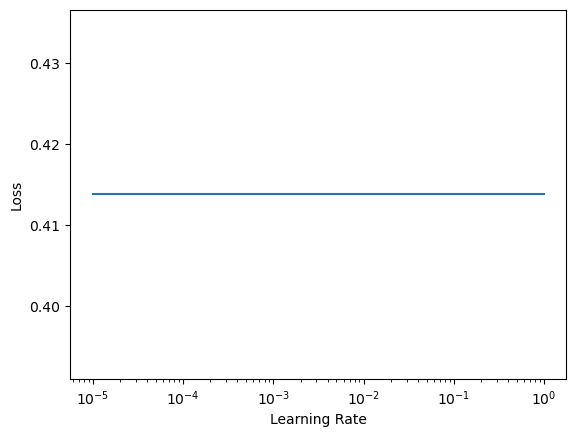

In [130]:
# 定义学习率范围测试函数
def find_lr(model, data, hk_model, initial_opinions, epsilon, max_iterations, labels, num_epochs=100, start_lr=1e-5, end_lr=1, smooth_f=0.05):
    #smooth_f是用于计算平滑损失函数值的参数
    # 创建Adam优化器
    optimizer = optim.Adam(model.parameters(), lr=start_lr)
    
    # 保存学习率和损失函数值的列表
    lrs = []
    losses = []
    best_loss = float('inf')
    
    # 学习率增大的步长
    lr_step = (end_lr - start_lr) / num_epochs
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)

        # 使用HK模型更新观点
        opinions = hk_model(initial_opinions, out.detach().numpy(), epsilon, max_iterations)
        actions = torch.tensor(opinions, dtype=torch.float32, requires_grad=True).view(-1, 1)

        # 计算损失函数
        loss = nn.MSELoss()(actions, torch.tensor(labels, dtype=torch.float32).view(-1, 1))
        loss.backward()
        optimizer.step()

        # 计算平滑的损失函数值
        if epoch == 0:
            smooth_loss = loss.item()
        else:
            smooth_loss = smooth_f * loss.item() + (1 - smooth_f) * smooth_loss

        # 判断是否出现了最优的损失函数值
        if smooth_loss < best_loss:
            best_loss = smooth_loss

        # 保存学习率和损失函数值
        lrs.append(optimizer.param_groups[0]['lr'])
        losses.append(smooth_loss)

        # 更新学习率
        optimizer.param_groups[0]['lr'] += lr_step

        print(f"Epoch: {epoch + 1}, Learning Rate: {lrs[-1]:.6f}, Loss: {losses[-1]:.6f}")

    # 绘制学习率和损失函数曲线
    plt.plot(lrs, losses)
    plt.xlabel('Learning Rate')
    plt.ylabel('Loss')
    plt.xscale('log')
    plt.show()

# 训练模型并寻找最优学习率
model = GraphSAGE(data.x.size(-1), 16, 1)
find_lr(model, data, hk_model, initial_opinions, epsilon, max_iterations, labels)


2.模型

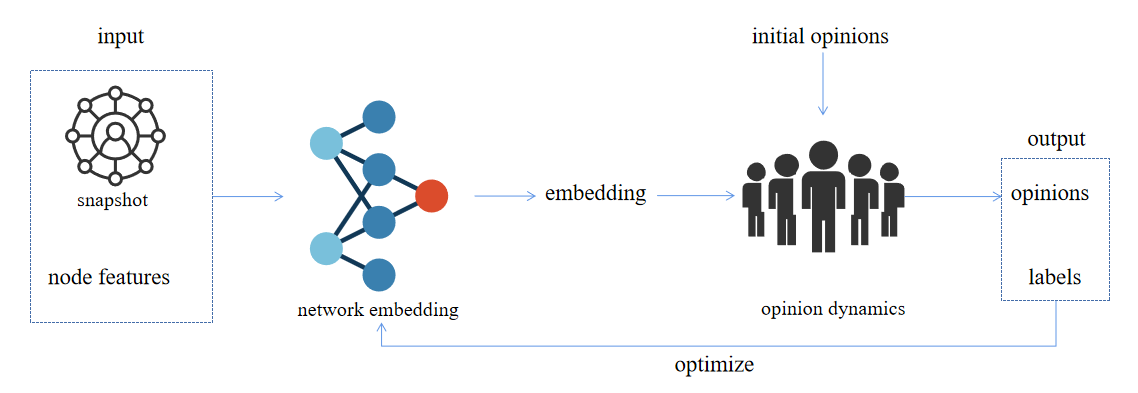

3.训练数据，只有最后一张快照进行了训练

## 3.3 网络嵌入+观点动力学——动态网络

框架图

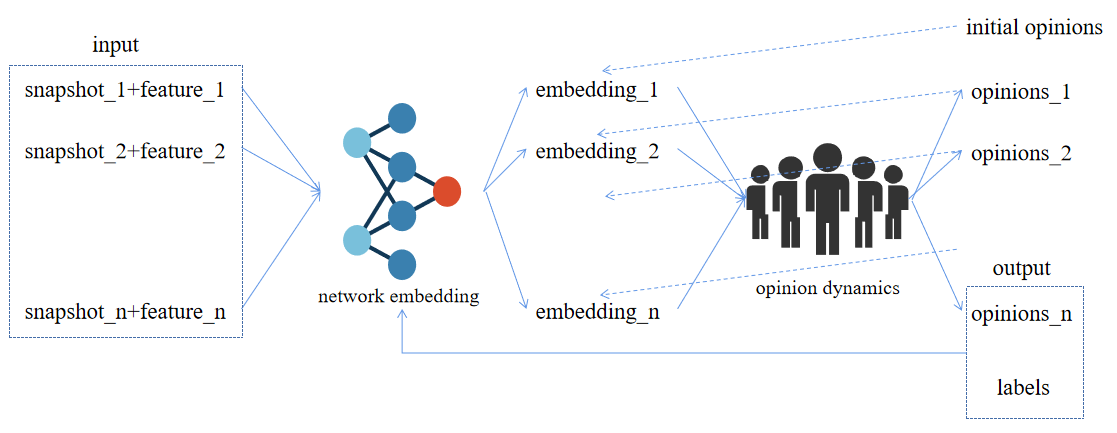

In [94]:
# 模型参数
epsilon = 0.1
max_iterations = 10
# 观点的动力学（使用HK模型）
def hk_model(opinions, features, epsilon, max_iterations):
    num_agents = len(opinions)
    iteration = 0

    while iteration < max_iterations:
        new_opinions = np.copy(opinions)

        for i in range(num_agents):
            similar_opinions = []
            for j in range(num_agents):
                if abs(opinions[j]-opinions[i]) < epsilon:
                    similar_opinions.append(features[j])

            if len(similar_opinions) > 0:
                similar_opinions = np.array(similar_opinions)
                new_opinions[i] = np.mean(similar_opinions, axis=0)

        opinions = np.copy(new_opinions)
        iteration += 1

    return opinions

In [122]:
def accuracy(predictions, labels):
    # 将预测值转换为二分类的结果（大于等于0.5为正类，小于0.5为负类）
    predicted_classes = (predictions >= 0.5).type(torch.float32)
    correct = (predicted_classes == labels).type(torch.float32)
    accuracy = correct.mean().item()
    return accuracy

In [123]:
def train_multiple_graphs(graphs, node_features, num_epochs=100):
    # 创建GraphSAGE模型和优化器
    model = GraphSAGE(node_features[0].shape[-1], 16, 1)
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    # 随机初始化观点
    initial_opinions = np.random.normal(loc=0.5, scale=0.1, size=max_nodes)

    # 初始化连续五次损失不变的计数器
    loss_not_improved_count = 0

    # 上一次迭代的损失值
    prev_loss = float('inf')

    for epoch in range(num_epochs):
        for t in range(len(graphs) - 1):
            # 获取当前时间快照图的边信息
            current_edges = list(graphs[t].edges())
            if len(current_edges) == 0:
                # 如果当前图中没有边，跳过当前图的处理
                continue
            current_edge_index = torch.tensor(current_edges).t().contiguous().to(torch.int64)
            data = Data(x=torch.tensor(node_features[t], dtype=torch.float32), edge_index=current_edge_index)
            # 不使用batch，直接处理当前时间快照图的数据
            current_out = model(data.x, data.edge_index)
            initial_opinions = hk_model(initial_opinions, current_out.detach().numpy(), epsilon, max_iterations)

        # 处理最后一张图的观点和标签
        last_x = torch.tensor(node_features[-1], dtype=torch.float32)
        last_edge_index = torch.tensor(list(graphs[-1].edges())).t().contiguous().to(torch.int64)
        last_data = Data(x=last_x, edge_index=last_edge_index)
        last_out = model(last_data.x, last_data.edge_index)
        last_opinions = hk_model(initial_opinions, last_out.detach().numpy(), epsilon, max_iterations)
        last_actions = torch.tensor(last_opinions, dtype=torch.float32, requires_grad=True).view(-1, 1)
        
        # Replace `labels` with the correct label data for the last graph
        last_labels = torch.tensor(labels, dtype=torch.float32).view(-1, 1)
        last_loss = nn.MSELoss()(last_actions, last_labels)

        # 反向传播和参数更新
        last_loss.backward()
        optimizer.step()
        #print(f"Epoch: {epoch+1}, Graph: {len(graphs)}, Loss: {last_loss.item():.4f}")
        
        # 输出当前模型在训练数据上的准确率
        train_accuracy = accuracy(last_actions, last_labels)
        print(f"Epoch: {epoch+1}, Graph: {len(graphs)}, Train Accuracy: {train_accuracy:.4f}，Loss: {last_loss.item():.4f}")


        # 检查是否达到终止条件（连续五次损失不变）
        if last_loss.item() >= prev_loss:
            loss_not_improved_count += 1
        else:
            loss_not_improved_count = 0

        if loss_not_improved_count >= 5:
            print("Loss has not improved for 5 consecutive epochs. Stopping training.")
            break

        # 更新上一次迭代的损失值
        prev_loss = last_loss.item()

# 训练模型
num_epochs = 100
train_multiple_graphs(graphs, node_features_new, num_epochs=num_epochs)


Epoch: 1, Graph: 89, Train Accuracy: 0.5862，Loss: 0.4138
Epoch: 2, Graph: 89, Train Accuracy: 0.5862，Loss: 0.4138
Epoch: 3, Graph: 89, Train Accuracy: 0.5862，Loss: 0.4138
Epoch: 4, Graph: 89, Train Accuracy: 0.5862，Loss: 0.4138
Epoch: 5, Graph: 89, Train Accuracy: 0.5862，Loss: 0.4138
Epoch: 6, Graph: 89, Train Accuracy: 0.5862，Loss: 0.4138
Loss has not improved for 5 consecutive epochs. Stopping training.


统计直播间的数据得到具有一般性质的直播间来进行训练不合理，需要大量直播间的数据来训练模型